# Traffic Flow Prediction — Model Evaluation

Notebook đánh giá hiệu quả của 3 model: **LSTM**, **GRU**, và **XGBoost**.

Nội dung:
1. Load data & models
2. Overall metrics (MSE, MAE, RMSE, R²)
3. Prediction vs Actual — scatter & timeseries
4. Error distribution
5. Per-node performance
6. Time-of-day analysis
7. Model comparison summary

In [1]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
print(f'Base directory: {BASE_DIR}')

Base directory: d:\Downloads\TreeSearch-main\COS30019\Models


## 1. Load Data & Models

In [2]:
# ── Model Definitions (must match model_training.py) ──

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])


class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        return self.fc(out[:, -1, :])

In [3]:
# ── Helper functions (must match model_training.py) ──

def cyclic_encode(values, max_val):
    sin = np.sin(2 * np.pi * values / max_val)
    cos = np.cos(2 * np.pi * values / max_val)
    return sin, cos


def build_cyclic_features(pivot_df):
    hour = pivot_df.index.hour
    minute = pivot_df.index.minute
    dow = pivot_df.index.dayofweek
    hour_sin, hour_cos = cyclic_encode(hour, 24)
    minute_sin, minute_cos = cyclic_encode(minute, 60)
    dow_sin, dow_cos = cyclic_encode(dow, 7)
    return np.column_stack([hour_sin, hour_cos, minute_sin, minute_cos, dow_sin, dow_cos])


def create_sequences(features, targets, seq_len=4):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(features)):
        X_seq.append(features[i - seq_len : i])
        y_seq.append(targets[i])
    return np.array(X_seq), np.array(y_seq)

In [4]:
# ── Load & preprocess data ──

df = pd.read_csv(os.path.join(BASE_DIR, 'processed_traffic_data.csv'))
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

pivot_df = df.pivot_table(
    index='Timestamp', columns='SCATS Number',
    values='Flow', aggfunc='mean'
).fillna(0).sort_index()

# Features & targets
X = build_cyclic_features(pivot_df)
target_cols = [c for c in pivot_df.columns if isinstance(c, (int, float, np.integer))]
y = pivot_df[target_cols].values

# Load scaler & metadata
scaler_y = joblib.load(os.path.join(BASE_DIR, 'scaler_y.pkl'))
node_ids = joblib.load(os.path.join(BASE_DIR, 'node_ids.pkl'))
metadata = joblib.load(os.path.join(BASE_DIR, 'model_metadata.pkl'))

SEQ_LEN = metadata['SEQ_LEN']
INPUT_SIZE = metadata['INPUT_SIZE']
HIDDEN_SIZE = metadata['HIDDEN_SIZE']
OUTPUT_SIZE = metadata['OUTPUT_SIZE']

y_scaled = scaler_y.transform(y)

# Prepare LSTM/GRU sequences
X_seq, y_seq = create_sequences(X, y_scaled, seq_len=SEQ_LEN)
timestamps_seq = pivot_df.index[SEQ_LEN:]  # aligned timestamps for sequences

print(f'Total samples: {len(X)}')
print(f'Sequence samples (LSTM/GRU): {len(X_seq)} (SEQ_LEN={SEQ_LEN})')
print(f'Nodes: {OUTPUT_SIZE}')
print(f'Features: {INPUT_SIZE} cyclic')
print(f'Date range: {pivot_df.index.min()} → {pivot_df.index.max()}')

Total samples: 2976
Sequence samples (LSTM/GRU): 2972 (SEQ_LEN=4)
Nodes: 40
Features: 6 cyclic
Date range: 2006-10-01 00:15:00 → 2006-11-01 00:00:00


In [17]:
# ── Load trained models ──

# LSTM
lstm_model = LSTMModel(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE, metadata['NUM_LAYERS'])
lstm_model.load_state_dict(
    torch.load(os.path.join(BASE_DIR, 'lstm_weights.pth'), map_location='cpu', weights_only=True)
)
lstm_model.eval()

# GRU
gru_model = GRUModel(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE, metadata['NUM_LAYERS'])
gru_model.load_state_dict(
    torch.load(os.path.join(BASE_DIR, 'gru_weights.pth'), map_location='cpu', weights_only=True)
)
gru_model.eval()

# XGBoost
xgb_model = joblib.load(os.path.join(BASE_DIR, 'xgboost_model.pkl'))

print('All 3 models loaded successfully.')

All 3 models loaded successfully.


## 2. Generate Predictions

In [6]:
# ── Predictions (scaled domain) ──

# LSTM
X_seq_t = torch.tensor(X_seq, dtype=torch.float32)
with torch.no_grad():
    lstm_preds_scaled = lstm_model(X_seq_t).numpy()

# GRU
with torch.no_grad():
    gru_preds_scaled = gru_model(X_seq_t).numpy()

# XGBoost (flat features, full dataset)
xgb_preds_scaled = xgb_model.predict(X)

# ── Inverse transform to real flow values ──
lstm_preds_real = scaler_y.inverse_transform(lstm_preds_scaled)
gru_preds_real = scaler_y.inverse_transform(gru_preds_scaled)
xgb_preds_real = scaler_y.inverse_transform(xgb_preds_scaled)

# Actual values (real domain)
y_actual_seq = scaler_y.inverse_transform(y_seq)      # for LSTM/GRU comparison
y_actual_full = y                                       # for XGBoost comparison

print(f'LSTM/GRU predictions shape: {lstm_preds_real.shape}')
print(f'XGBoost predictions shape:  {xgb_preds_real.shape}')

LSTM/GRU predictions shape: (2972, 40)
XGBoost predictions shape:  (2976, 40)


## 3. Overall Metrics — MSE, MAE, RMSE, R²

In [7]:
def compute_metrics(y_true, y_pred, model_name):
    """Compute regression metrics for a model."""
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R²': r2}


# Compute on SCALED values (for fair comparison)
metrics_scaled = pd.DataFrame([
    compute_metrics(y_seq, lstm_preds_scaled, 'LSTM'),
    compute_metrics(y_seq, gru_preds_scaled, 'GRU'),
    compute_metrics(y_scaled, xgb_preds_scaled, 'XGBoost'),
])

# Compute on REAL values
metrics_real = pd.DataFrame([
    compute_metrics(y_actual_seq, lstm_preds_real, 'LSTM'),
    compute_metrics(y_actual_seq, gru_preds_real, 'GRU'),
    compute_metrics(y_actual_full, xgb_preds_real, 'XGBoost'),
])

print('=== Metrics on SCALED data [0, 1] ===')
display(metrics_scaled.set_index('Model').style.format('{:.6f}').background_gradient(cmap='RdYlGn_r', subset=['MSE', 'MAE', 'RMSE']).background_gradient(cmap='RdYlGn', subset=['R²']))

print('\n=== Metrics on REAL flow values ===')
display(metrics_real.set_index('Model').style.format('{:.4f}').background_gradient(cmap='RdYlGn_r', subset=['MSE', 'MAE', 'RMSE']).background_gradient(cmap='RdYlGn', subset=['R²']))

=== Metrics on SCALED data [0, 1] ===


,MSE,MAE,RMSE,R²
Model,,,,
LSTM,0.006364,0.041473,0.079777,0.919723
GRU,0.006357,0.041415,0.079733,0.919716
XGBoost,0.005901,0.036667,0.076820,0.926245



=== Metrics on REAL flow values ===


,MSE,MAE,RMSE,R²
Model,,,,
LSTM,542.5690,11.5183,23.2931,0.9197
GRU,542.8591,11.5219,23.2993,0.9197
XGBoost,504.2882,10.2335,22.4564,0.9262


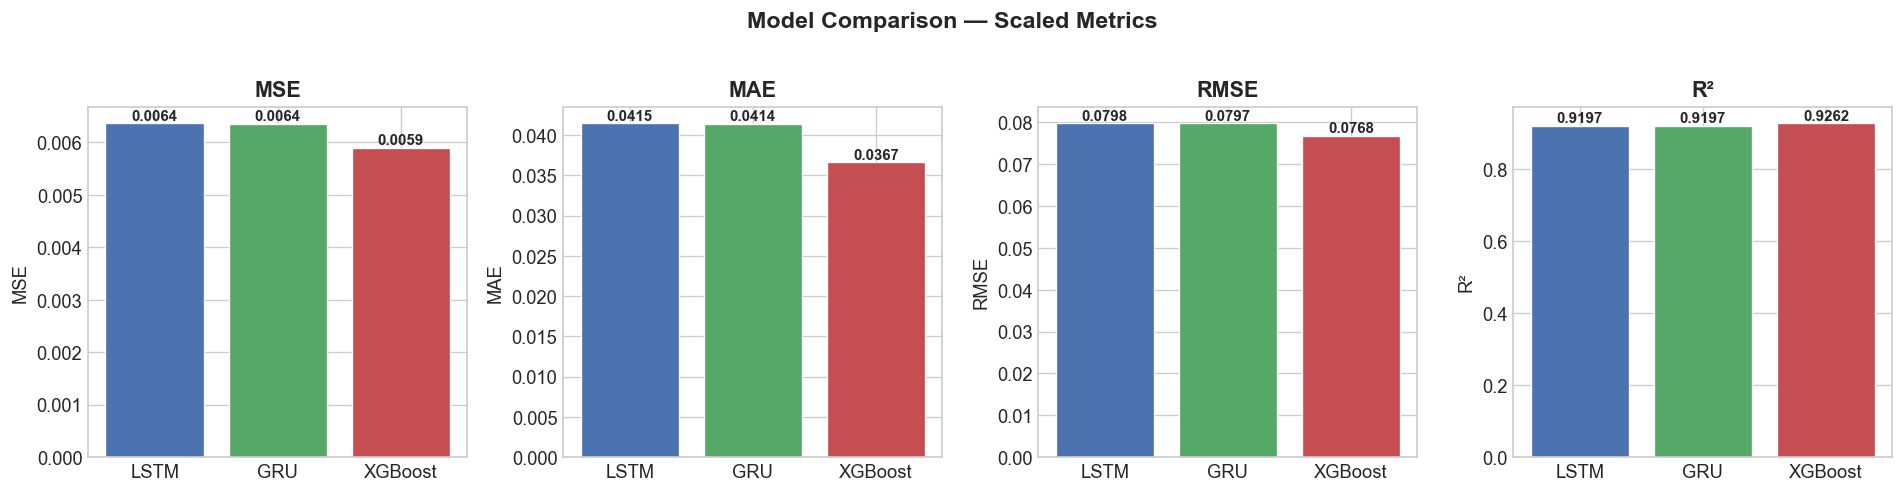

In [8]:
# ── Bar chart comparison ──

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['#4C72B0', '#55A868', '#C44E52']
model_names = ['LSTM', 'GRU', 'XGBoost']

for ax, metric in zip(axes, ['MSE', 'MAE', 'RMSE', 'R²']):
    values = metrics_scaled.set_index('Model')[metric].values
    bars = ax.bar(model_names, values, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('Model Comparison — Scaled Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Prediction vs Actual — Scatter Plots

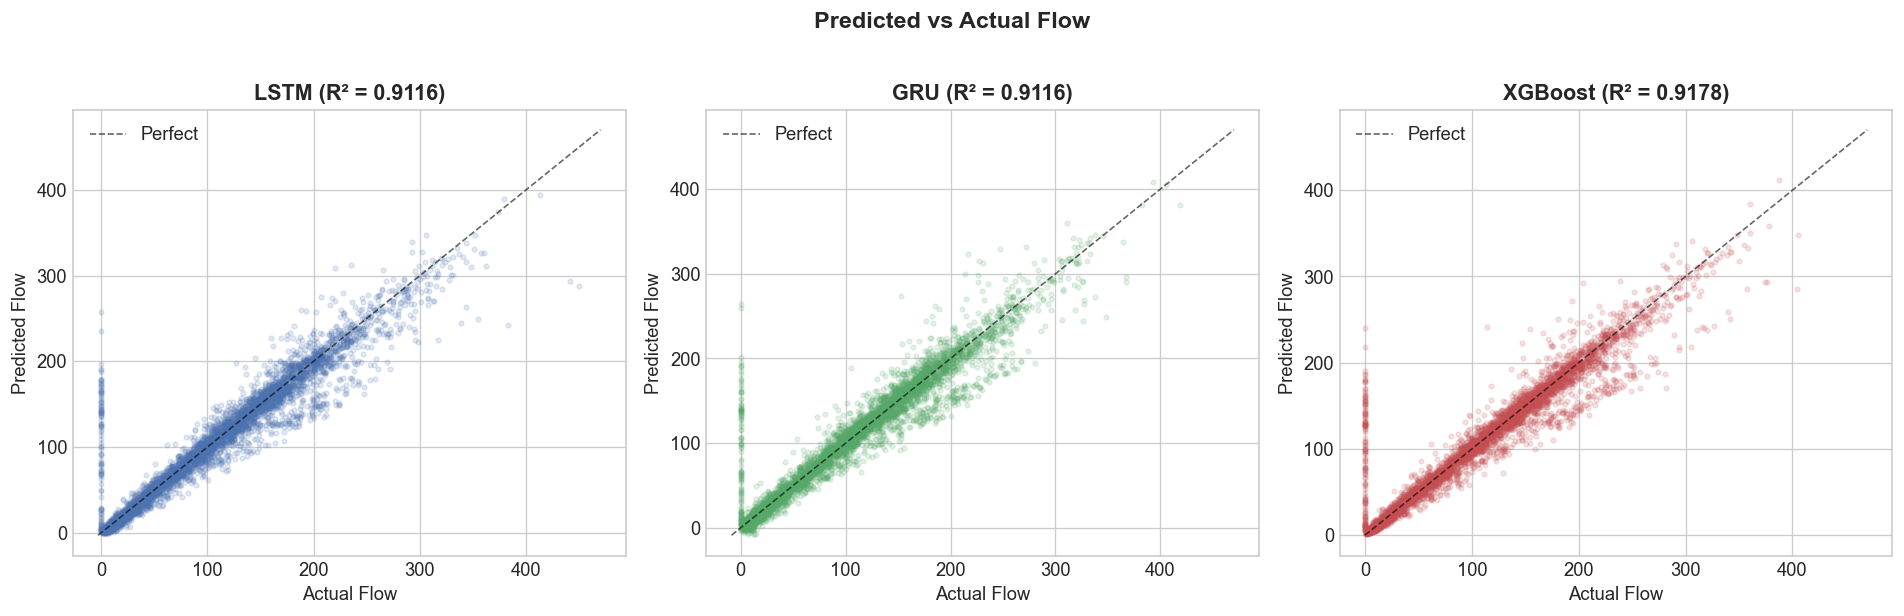

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

datasets = [
    ('LSTM',    y_actual_seq.flatten(), lstm_preds_real.flatten(), '#4C72B0'),
    ('GRU',     y_actual_seq.flatten(), gru_preds_real.flatten(),  '#55A868'),
    ('XGBoost', y_actual_full.flatten(), xgb_preds_real.flatten(), '#C44E52'),
]

for ax, (name, actual, pred, color) in zip(axes, datasets):
    # Sample 5000 points for readability
    idx = np.random.choice(len(actual), min(5000, len(actual)), replace=False)
    ax.scatter(actual[idx], pred[idx], alpha=0.15, s=8, color=color)
    
    # Perfect prediction line
    lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.6, label='Perfect')
    
    r2 = r2_score(actual, pred)
    ax.set_title(f'{name} (R² = {r2:.4f})')
    ax.set_xlabel('Actual Flow')
    ax.set_ylabel('Predicted Flow')
    ax.legend(loc='upper left')

fig.suptitle('Predicted vs Actual Flow', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Error Distribution

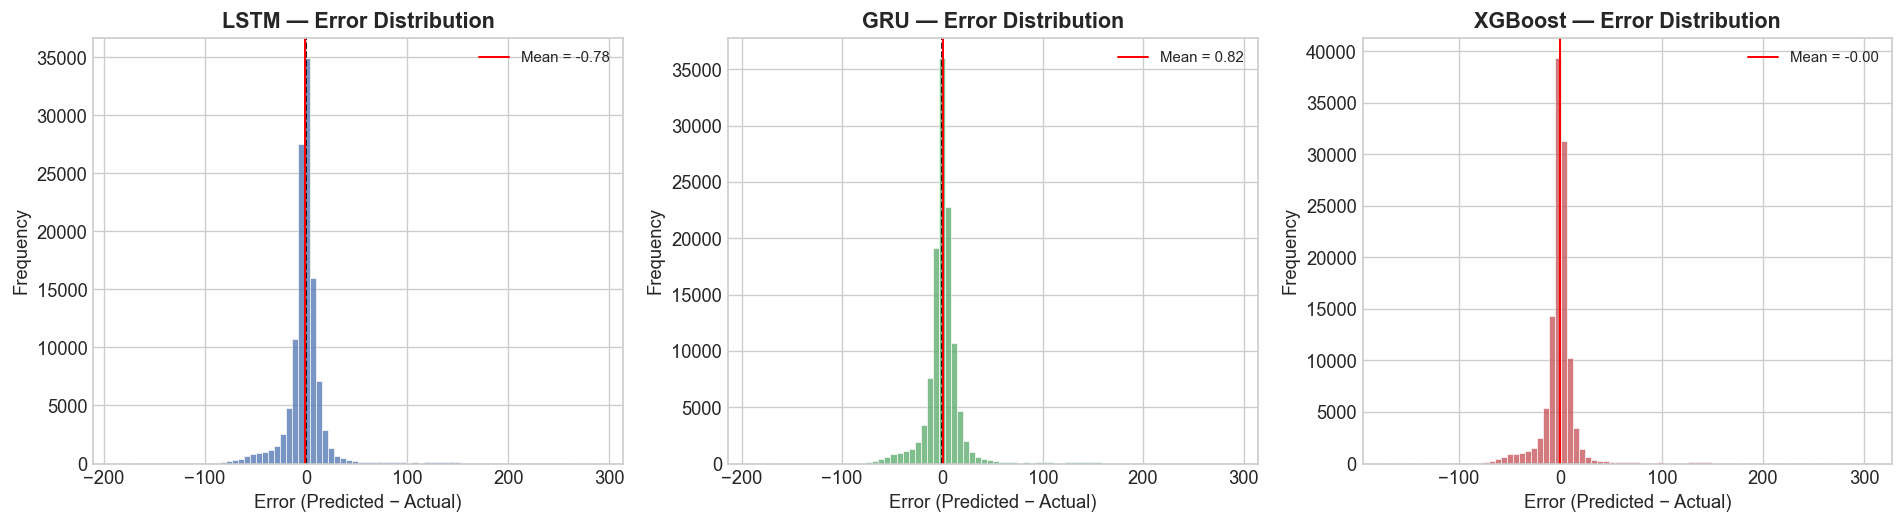

,Mean Error,Std Error,Median Error,Max |Error|,95th %ile |Error|
Model,,,,,
LSTM,-0.78,23.28,-1.25,289.79,44.79
GRU,0.82,23.28,-0.22,290.14,42.10
XGBoost,-0.00,22.46,-0.16,303.78,41.74


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

errors = [
    ('LSTM',    (lstm_preds_real - y_actual_seq).flatten(),  '#4C72B0'),
    ('GRU',     (gru_preds_real - y_actual_seq).flatten(),   '#55A868'),
    ('XGBoost', (xgb_preds_real - y_actual_full).flatten(),  '#C44E52'),
]

for ax, (name, err, color) in zip(axes, errors):
    ax.hist(err, bins=80, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.axvline(err.mean(), color='red', linewidth=1.2, linestyle='-', label=f'Mean = {err.mean():.2f}')
    ax.set_title(f'{name} — Error Distribution')
    ax.set_xlabel('Error (Predicted − Actual)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Error statistics table
error_stats = pd.DataFrame({
    'Model': ['LSTM', 'GRU', 'XGBoost'],
    'Mean Error': [e[1].mean() for e in errors],
    'Std Error': [e[1].std() for e in errors],
    'Median Error': [np.median(e[1]) for e in errors],
    'Max |Error|': [np.abs(e[1]).max() for e in errors],
    '95th %ile |Error|': [np.percentile(np.abs(e[1]), 95) for e in errors],
}).set_index('Model')

display(error_stats.style.format('{:.2f}'))

## 6. Per-Node Performance (MAE by SCATS Node)

In [11]:
# Compute MAE per node for each model
per_node_mae = pd.DataFrame({'Node': [str(n) for n in node_ids]})

lstm_node_mae = np.abs(lstm_preds_real - y_actual_seq).mean(axis=0)
gru_node_mae = np.abs(gru_preds_real - y_actual_seq).mean(axis=0)
xgb_node_mae = np.abs(xgb_preds_real - y_actual_full).mean(axis=0)

per_node_mae['LSTM'] = lstm_node_mae
per_node_mae['GRU'] = gru_node_mae
per_node_mae['XGBoost'] = xgb_node_mae
per_node_mae = per_node_mae.set_index('Node')

# Sort by XGBoost MAE for readability
per_node_mae = per_node_mae.sort_values('XGBoost', ascending=False)

print(f'Per-node MAE (real flow values) — {len(node_ids)} nodes')
display(per_node_mae.style.format('{:.2f}').background_gradient(cmap='OrRd', axis=None))

Per-node MAE (real flow values) — 40 nodes


,LSTM,GRU,XGBoost
Node,,,
4262,38.10,37.98,36.51
3127,35.89,35.44,34.53
3002,34.44,34.19,33.49
4263,32.76,32.49,31.69
4812,26.39,26.15,25.75
3685,22.20,22.52,20.72
3001,22.98,23.95,20.35
2000,23.36,22.58,20.35
3812,15.37,15.94,13.44


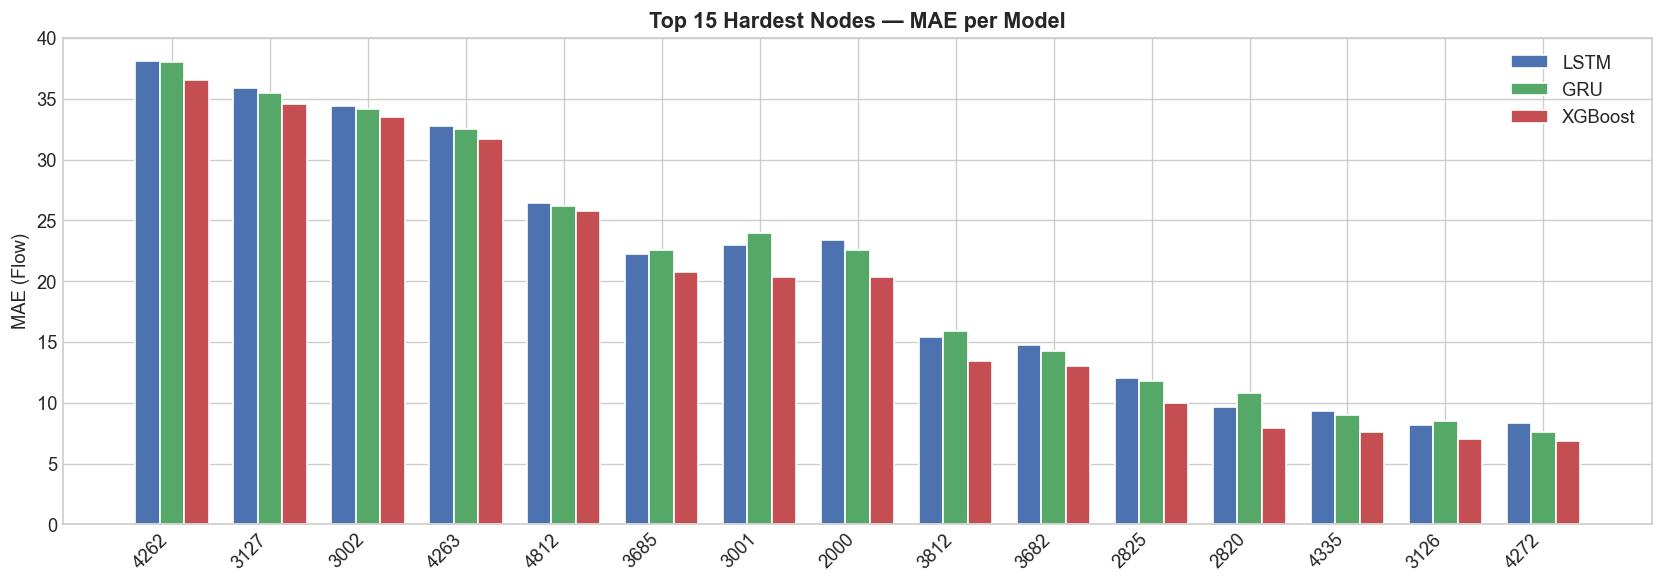

In [12]:
# ── Per-node MAE bar chart (top 15 hardest nodes) ──

top_n = min(15, len(per_node_mae))
top_nodes = per_node_mae.head(top_n)

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(top_n)
w = 0.25

ax.bar(x - w, top_nodes['LSTM'],    width=w, label='LSTM',    color='#4C72B0', edgecolor='white')
ax.bar(x,     top_nodes['GRU'],     width=w, label='GRU',     color='#55A868', edgecolor='white')
ax.bar(x + w, top_nodes['XGBoost'], width=w, label='XGBoost', color='#C44E52', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(top_nodes.index, rotation=45, ha='right')
ax.set_ylabel('MAE (Flow)')
ax.set_title(f'Top {top_n} Hardest Nodes — MAE per Model')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Time-of-Day Analysis

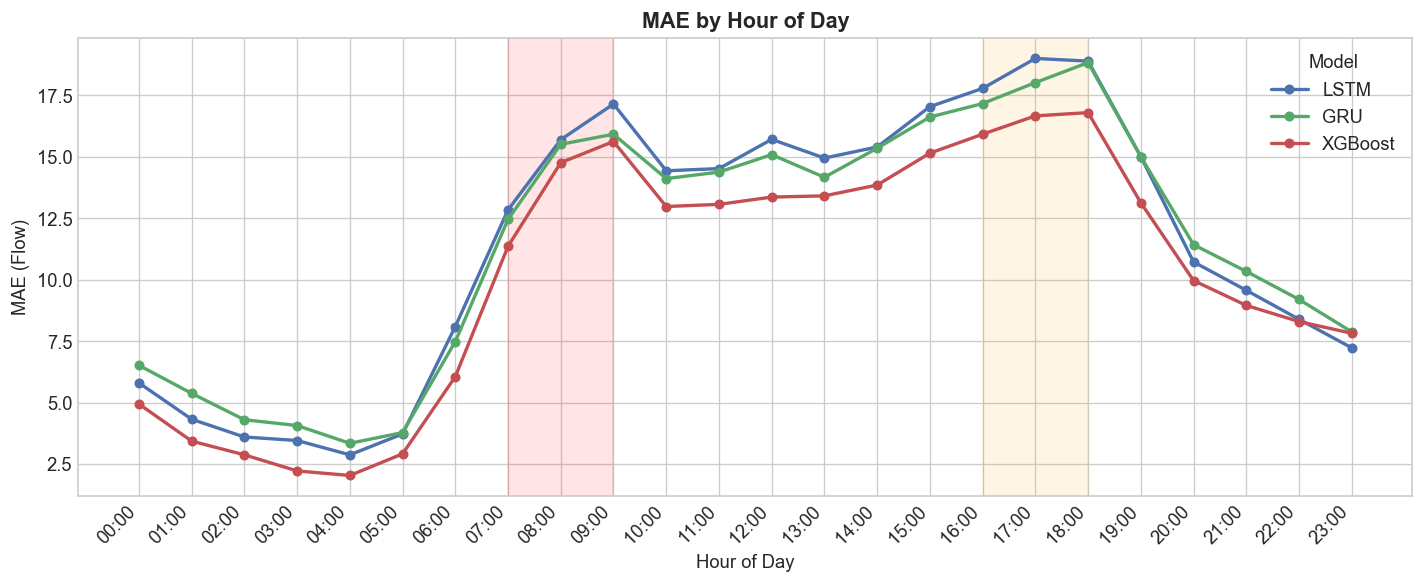


MAE by Hour:


,LSTM,GRU,XGBoost
Hour,,,
0,5.80,6.52,4.94
1,4.32,5.38,3.43
2,3.60,4.30,2.87
3,3.46,4.07,2.22
4,2.87,3.34,2.03
5,3.72,3.78,2.91
6,8.09,7.48,6.06
7,12.84,12.46,11.36
8,15.70,15.51,14.76


In [13]:
# Compute MAE by hour of day
hours_seq = timestamps_seq.hour
hours_full = pivot_df.index.hour

hourly_mae = pd.DataFrame()

for h in range(24):
    mask_seq = (hours_seq == h)
    mask_full = (hours_full == h)
    
    if mask_seq.sum() == 0 or mask_full.sum() == 0:
        continue
    
    hourly_mae.loc[h, 'LSTM']    = np.abs(lstm_preds_real[mask_seq] - y_actual_seq[mask_seq]).mean()
    hourly_mae.loc[h, 'GRU']     = np.abs(gru_preds_real[mask_seq]  - y_actual_seq[mask_seq]).mean()
    hourly_mae.loc[h, 'XGBoost'] = np.abs(xgb_preds_real[mask_full] - y_actual_full[mask_full]).mean()

hourly_mae.index.name = 'Hour'

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
hourly_mae.plot(ax=ax, marker='o', markersize=5, linewidth=2,
                color=['#4C72B0', '#55A868', '#C44E52'])

ax.set_xlabel('Hour of Day')
ax.set_ylabel('MAE (Flow)')
ax.set_title('MAE by Hour of Day')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
ax.legend(title='Model')
ax.axvspan(7, 9, alpha=0.1, color='red', label='Morning rush')
ax.axvspan(16, 18, alpha=0.1, color='orange', label='Evening rush')
plt.tight_layout()
plt.show()

print('\nMAE by Hour:')
display(hourly_mae.style.format('{:.2f}').background_gradient(cmap='OrRd', axis=None))

## 8. Time Series — Actual vs Predicted (Sample Node)

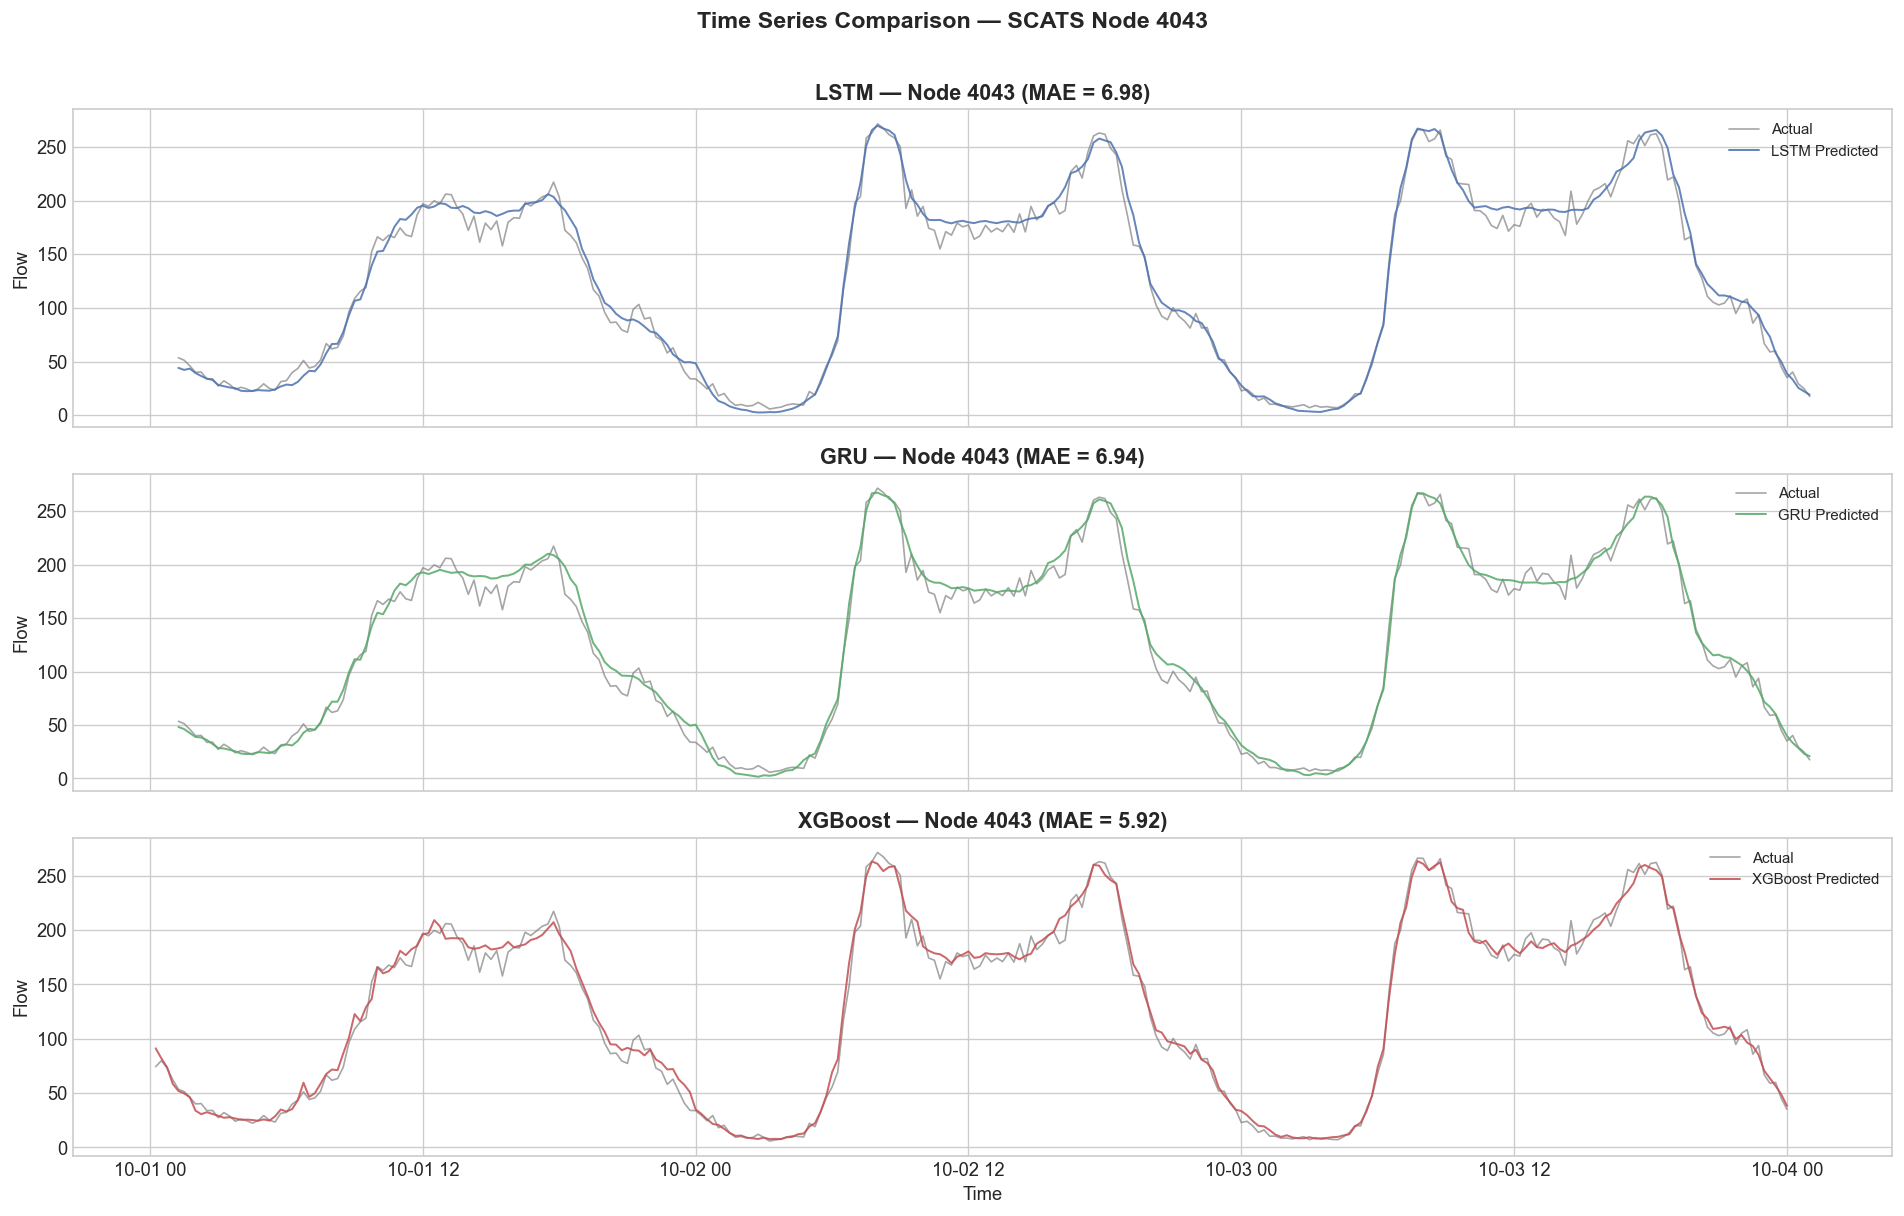

In [14]:
# Pick a sample node (median MAE across all models)
median_mae_per_node = per_node_mae.mean(axis=1)
sample_node_label = median_mae_per_node.sort_values().index[len(median_mae_per_node) // 2]
node_idx = [str(n) for n in node_ids].index(sample_node_label)

# Get first 3 days of data for clearer visualization
n_show = min(96 * 3, len(timestamps_seq))  # 96 intervals/day × 3 days

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

models_data = [
    ('LSTM',    timestamps_seq[:n_show], y_actual_seq[:n_show, node_idx], lstm_preds_real[:n_show, node_idx], '#4C72B0'),
    ('GRU',     timestamps_seq[:n_show], y_actual_seq[:n_show, node_idx], gru_preds_real[:n_show, node_idx],  '#55A868'),
    ('XGBoost', pivot_df.index[:n_show], y_actual_full[:n_show, node_idx], xgb_preds_real[:n_show, node_idx],  '#C44E52'),
]

for ax, (name, ts, actual, pred, color) in zip(axes, models_data):
    ax.plot(ts, actual, color='gray', linewidth=1, alpha=0.7, label='Actual')
    ax.plot(ts, pred, color=color, linewidth=1.2, alpha=0.85, label=f'{name} Predicted')
    mae = np.abs(pred - actual).mean()
    ax.set_ylabel('Flow')
    ax.set_title(f'{name} — Node {sample_node_label} (MAE = {mae:.2f})')
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Time')
fig.suptitle(f'Time Series Comparison — SCATS Node {sample_node_label}',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Day-of-Week Analysis

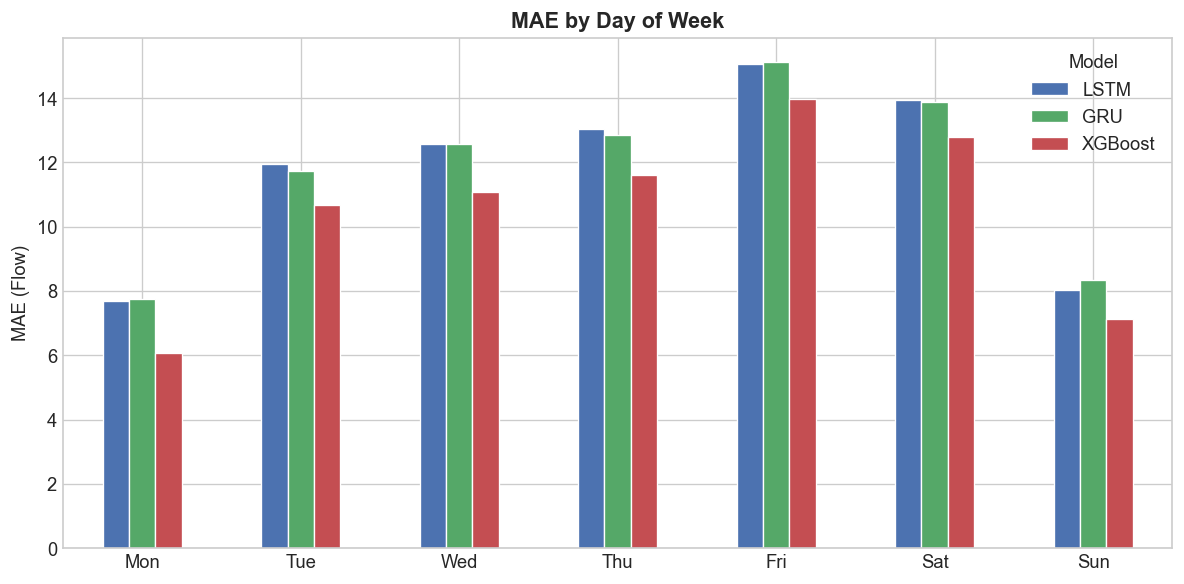

,LSTM,GRU,XGBoost
Mon,7.70,7.76,6.06
Tue,11.94,11.74,10.68
Wed,12.59,12.58,11.09
Thu,13.04,12.86,11.62
Fri,15.06,15.13,13.97
Sat,13.94,13.89,12.78
Sun,8.04,8.33,7.12


In [15]:
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_seq = timestamps_seq.dayofweek
dow_full = pivot_df.index.dayofweek

dow_mae = pd.DataFrame()

for d in range(7):
    mask_seq = (dow_seq == d)
    mask_full = (dow_full == d)
    
    if mask_seq.sum() == 0 or mask_full.sum() == 0:
        continue
    
    dow_mae.loc[dow_names[d], 'LSTM']    = np.abs(lstm_preds_real[mask_seq] - y_actual_seq[mask_seq]).mean()
    dow_mae.loc[dow_names[d], 'GRU']     = np.abs(gru_preds_real[mask_seq]  - y_actual_seq[mask_seq]).mean()
    dow_mae.loc[dow_names[d], 'XGBoost'] = np.abs(xgb_preds_real[mask_full] - y_actual_full[mask_full]).mean()

fig, ax = plt.subplots(figsize=(10, 5))
dow_mae.plot(kind='bar', ax=ax, color=['#4C72B0', '#55A868', '#C44E52'],
             edgecolor='white', linewidth=0.8)
ax.set_ylabel('MAE (Flow)')
ax.set_title('MAE by Day of Week')
ax.set_xticklabels(dow_mae.index, rotation=0)
ax.legend(title='Model')
plt.tight_layout()
plt.show()

display(dow_mae.style.format('{:.2f}').background_gradient(cmap='OrRd', axis=None))

## 10. Summary & Conclusion

In [16]:
print('=' * 60)
print('MODEL EVALUATION SUMMARY')
print('=' * 60)
print(f'\nDataset: SCATS October 2006')
print(f'Nodes: {OUTPUT_SIZE}')
print(f'Samples: {len(X)}')
print(f'Features: {INPUT_SIZE} (cyclic sin/cos encoding)')
print(f'LSTM/GRU sequence length: {SEQ_LEN} (= {SEQ_LEN * 15} min history)')
print()

# Final comparison table
summary = metrics_scaled.set_index('Model')[['MSE', 'MAE', 'RMSE', 'R²']].copy()
summary['Rank (MSE)'] = summary['MSE'].rank().astype(int)

best = summary['MSE'].idxmin()
print(f'Best model by MSE: {best}')
print()
display(summary.style.format({'MSE': '{:.6f}', 'MAE': '{:.6f}', 'RMSE': '{:.6f}', 'R²': '{:.4f}', 'Rank (MSE)': '{:.0f}'}).highlight_min(subset=['MSE', 'MAE', 'RMSE'], color='#d4edda').highlight_max(subset=['R²'], color='#d4edda'))

MODEL EVALUATION SUMMARY

Dataset: SCATS October 2006
Nodes: 40
Samples: 2976
Features: 6 (cyclic sin/cos encoding)
LSTM/GRU sequence length: 4 (= 60 min history)

Best model by MSE: XGBoost



,MSE,MAE,RMSE,R²,Rank (MSE)
Model,,,,,
LSTM,0.006364,0.041473,0.079777,0.9197,3
GRU,0.006357,0.041415,0.079733,0.9197,2
XGBoost,0.005901,0.036667,0.076820,0.9262,1
